# 02 — Exploratory Data Analysis

**Phase 1 — Data Engineering | MVP ladder: pre-MVP**

**Goal:** Surface the structure of MMHS150K beyond raw class counts, and answer specific questions that drive downstream design decisions in notebooks 03–06.

### Questions this EDA must answer

| # | Question | Drives |
|---|----------|--------|
| Q1 | Are all 149,819 image files present on disk? | Whether to drop rows before MVP 2 |
| Q2 | What's the tweet-length distribution? | RoBERTa `max_seq_len` choice (default 128) |
| Q3 | Is annotator agreement (T3) uniform across hate classes, or e.g. is `OtherHate` more ambiguous? | T3 deployment routing thresholds |
| Q4 | Do hate vs non-hate tweets differ in URL/hashtag/mention/emoji frequency? | Structured-feature engineering (notebook 03) |
| Q5 | What fraction of images have OCR text? Does it vary by hate category? | Viability of the OCR-only ablation cell |
| Q6 | What's the image dimension distribution? | Validates the 224×224 resize choice |
| Q7 | Are official splits balanced for T1/T2? | Whether per-split metrics are directly comparable |
| Q8 | Were extended-annotator rows (n=4,5) mostly NotHate? | Confirms the AAVE/contested-case curation hypothesis |

All charts saved to `outputs/eda_*.png` (per CLAUDE.md). Internal exploration only — no raw hate text shown in saved charts.


In [1]:
import ast
import json
import random
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

random.seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR     = PROJECT_ROOT / "data" / "MMHS150K"
PROCESSED    = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR  = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

IMG_DIR    = DATA_DIR / "img_resized"
OCR_DIR    = DATA_DIR / "img_txt"
SPLITS_DIR = DATA_DIR / "splits"

T2_LABELS = {0: "NotHate", 1: "Racist", 2: "Sexist", 3: "Homophobe", 4: "Religion", 5: "OtherHate"}
T2_ORDER  = [T2_LABELS[i] for i in range(6)]

# Load the processed labels (CSV needs literal_eval for list columns)
df = pd.read_csv(
    PROCESSED / "labels_parsed.csv",
    converters={"labels": ast.literal_eval, "labels_str": ast.literal_eval},
    dtype={"tweet_id": str, "img_filename": str},
    keep_default_na=True,
)
# Cast back to compact dtypes (CSV round-trip widens them)
df["T1"]           = df["T1"].astype("int8")
df["T2"]           = df["T2"].astype("Int8")          # nullable
df["T3"]           = df["T3"].astype("float32")
df["n_annotators"] = df["n_annotators"].astype("int8")
df["t2_valid"]     = df["t2_valid"].astype(bool)

print("df.shape:", df.shape)
print("Nulls per column:")
print(df.isna().sum())
print("\ndtypes:")
print(df.dtypes)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"


df.shape: (149819, 10)
Nulls per column:
tweet_id            0
tweet_text          0
img_filename        0
labels              0
labels_str          0
T1                  0
T2              11710
T3                  0
n_annotators        0
t2_valid            0
dtype: int64

dtypes:
tweet_id            str
tweet_text          str
img_filename        str
labels           object
labels_str       object
T1                 int8
T2                 Int8
T3              float32
n_annotators       int8
t2_valid           bool
dtype: object


In [2]:
# Q1 — Image accessibility audit
# Strategy: scan IMG_DIR once, build a set of existing filenames, then check
# membership against df["img_filename"]. ~150k Path.exists() calls would be
# slow on Windows NTFS; one iterdir is O(N) and runs in a few seconds.

print(f"Scanning {IMG_DIR} ...")
existing_imgs = {p.name for p in IMG_DIR.iterdir() if p.suffix.lower() == ".jpg"}
print(f"Found {len(existing_imgs):,} .jpg files in img_resized/")

df["img_exists"] = df["img_filename"].isin(existing_imgs)
present = int(df["img_exists"].sum())
missing = int((~df["img_exists"]).sum())

print(f"\nImage accessibility:")
print(f"  Present : {present:,}  ({present/len(df)*100:.2f}%)")
print(f"  Missing : {missing:,}  ({missing/len(df)*100:.2f}%)")

if missing > 0:
    missing_ids = df.loc[~df["img_exists"], "tweet_id"].tolist()
    missing_path = OUTPUTS_DIR / "missing_images.txt"
    missing_path.write_text("\n".join(missing_ids))
    print(f"  First 10 missing tweet_ids: {missing_ids[:10]}")
    print(f"  Full list -> {missing_path}")

# Files in img_resized/ that are NOT referenced by any df row (orphan check)
orphans = existing_imgs - set(df["img_filename"])
print(f"\nOrphan .jpg files (in img_resized/ but no GT entry): {len(orphans):,}")
if 0 < len(orphans) <= 5:
    print(f"  Examples: {list(orphans)[:5]}")

print("\ndf.shape:", df.shape)
print("img_exists nulls:", int(df["img_exists"].isna().sum()))


Scanning /teamspace/studios/this_studio/HateFusion/data/MMHS150K/img_resized ...


Found 150,000 .jpg files in img_resized/



Image accessibility:
  Present : 149,819  (100.00%)
  Missing : 0  (0.00%)

Orphan .jpg files (in img_resized/ but no GT entry): 181

df.shape: (149819, 11)
img_exists nulls: 0


Char-length percentiles:
count    149819.0
mean         84.7
std          28.2
min          28.0
50%          82.0
90%         126.0
95%         133.0
99%         139.0
max         164.0
Name: tweet_text_len_chars, dtype: float64

Word-count percentiles:
count    149819.0
mean         11.5
std           5.1
min           2.0
50%          11.0
90%          19.0
95%          21.0
99%          24.0
max          38.0
Name: tweet_text_len_words, dtype: float64


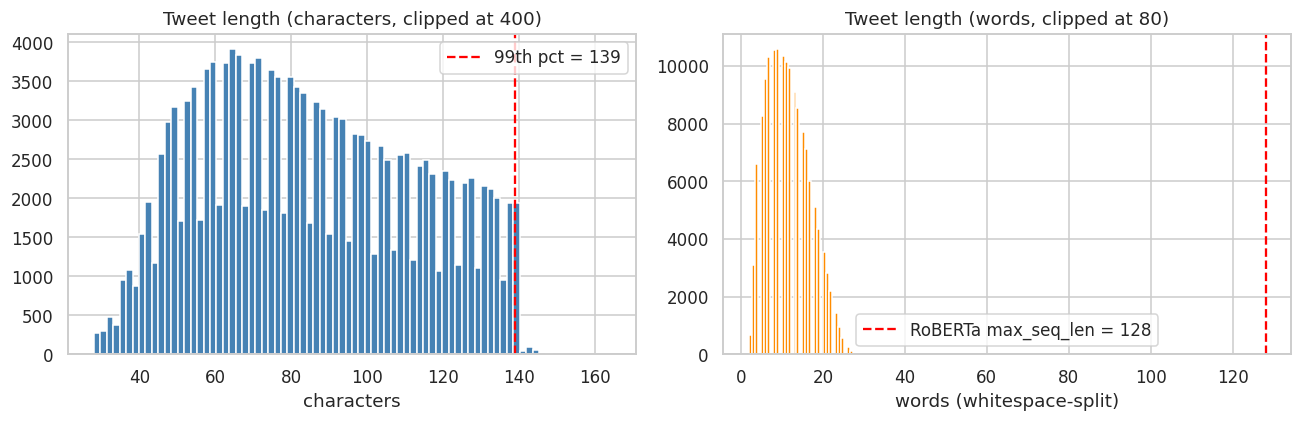


100.00% of tweets are <= 128 words.
RoBERTa BPE tokenises at roughly 1.3-1.6x word count for English social text.
Verdict: max_seq_len=128 should cover >99% of tweets after tokenisation. Re-verify in MVP 1.

df.shape: (149819, 13) | nulls in new cols: 0


In [3]:
# Q2 — Tweet length distribution (drives RoBERTa max_seq_len choice)
df["tweet_text_len_chars"] = df["tweet_text"].str.len()
df["tweet_text_len_words"] = df["tweet_text"].str.split().str.len()

print("Char-length percentiles:")
print(df["tweet_text_len_chars"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(1))
print("\nWord-count percentiles:")
print(df["tweet_text_len_words"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["tweet_text_len_chars"].clip(upper=400), bins=80, color="steelblue", edgecolor="white")
axes[0].set_title("Tweet length (characters, clipped at 400)")
axes[0].set_xlabel("characters")
axes[0].axvline(df["tweet_text_len_chars"].quantile(0.99), color="red", linestyle="--",
                label=f"99th pct = {df['tweet_text_len_chars'].quantile(0.99):.0f}")
axes[0].legend()

axes[1].hist(df["tweet_text_len_words"].clip(upper=80), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Tweet length (words, clipped at 80)")
axes[1].set_xlabel("words (whitespace-split)")
axes[1].axvline(128, color="red", linestyle="--", label="RoBERTa max_seq_len = 128")
axes[1].legend()

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "eda_tweet_length.png", dpi=120)
plt.show()

pct_under_128_words = (df["tweet_text_len_words"] <= 128).mean() * 100
print(f"\n{pct_under_128_words:.2f}% of tweets are <= 128 words.")
print("RoBERTa BPE tokenises at roughly 1.3-1.6x word count for English social text.")
print("Verdict: max_seq_len=128 should cover >99% of tweets after tokenisation. Re-verify in MVP 1.")

print("\ndf.shape:", df.shape, "| nulls in new cols:", int(df[['tweet_text_len_chars','tweet_text_len_words']].isna().sum().sum()))


T3 statistics per T2 class:
            mean  median    q25    q75       n
T2_name                                       
NotHate    0.838   1.000  0.667  1.000  112842
Racist     0.714   0.667  0.667  0.667   11927
Sexist     0.705   0.667  0.667  0.667    3495
Homophobe  0.743   0.667  0.667  0.667    3871
Religion   0.714   0.667  0.667  0.667     163
OtherHate  0.728   0.667  0.667  0.667    5811


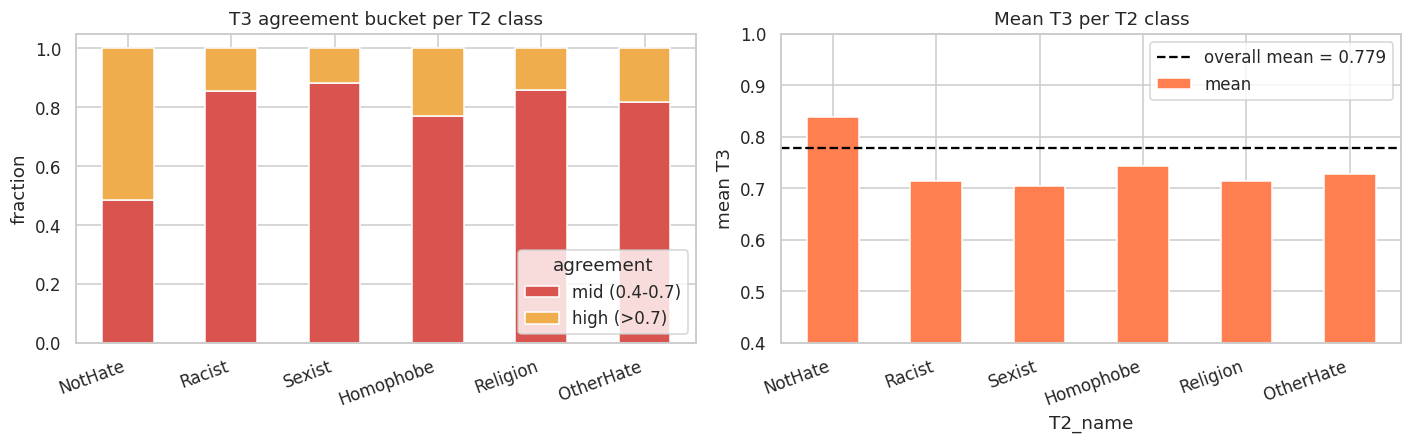


Lowest-agreement class: Sexist (mean T3 = 0.705)
Highest-agreement class: NotHate (mean T3 = 0.838)
→ Lowest-agreement class will both be hardest for the model AND the strongest candidate
  for human-review routing in the deployment story (Section 5 of framing doc).


In [4]:
# Q3 — Annotator agreement (T3) by T2 class
# Reveals which hate categories are most ambiguous and therefore best candidates
# for the human-in-the-loop deployment routing built on top of T3.

t2_t3 = df.dropna(subset=["T2"]).copy()
t2_t3["T2_name"] = t2_t3["T2"].map(T2_LABELS)
agg = t2_t3.groupby("T2_name")["T3"].agg(
    mean="mean", median="median", q25=lambda s: s.quantile(0.25),
    q75=lambda s: s.quantile(0.75), n="count",
).round(3).reindex(T2_ORDER)
print("T3 statistics per T2 class:")
print(agg)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# (a) Stacked bar of T3 buckets per class
buckets = pd.cut(t2_t3["T3"], bins=[-0.01, 0.4, 0.7, 1.01],
                 labels=["low (<0.4)", "mid (0.4-0.7)", "high (>0.7)"])
ct = pd.crosstab(t2_t3["T2"].map(T2_LABELS), buckets, normalize="index").reindex(T2_ORDER).round(3)
ct.plot(kind="bar", stacked=True, ax=axes[0], color=["#d9534f", "#f0ad4e", "#5cb85c"], edgecolor="white")
axes[0].set_title("T3 agreement bucket per T2 class")
axes[0].set_ylabel("fraction")
axes[0].set_xlabel("")
axes[0].legend(title="agreement", loc="lower right")
plt.setp(axes[0].get_xticklabels(), rotation=20, ha="right")

# (b) Mean T3 per class
agg["mean"].plot(kind="bar", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Mean T3 per T2 class")
axes[1].set_ylabel("mean T3")
axes[1].set_ylim(0.4, 1.0)
axes[1].axhline(df["T3"].mean(), color="black", linestyle="--",
                label=f"overall mean = {df['T3'].mean():.3f}")
axes[1].legend()
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "eda_t3_by_class.png", dpi=120)
plt.show()

worst = agg["mean"].idxmin()
best  = agg["mean"].idxmax()
print(f"\nLowest-agreement class: {worst} (mean T3 = {agg.loc[worst, 'mean']:.3f})")
print(f"Highest-agreement class: {best} (mean T3 = {agg.loc[best, 'mean']:.3f})")
print("→ Lowest-agreement class will both be hardest for the model AND the strongest candidate")
print("  for human-review routing in the deployment story (Section 5 of framing doc).")


Mean per-tweet counts (full dataset, n=149,819):
         n_urls  n_hashtags  n_mentions  n_emoji
T1                                              
no_hate   1.066       0.191       0.520    0.600
hate      1.063       0.241       0.565    0.427

Hate/NoHate ratio (>1 = more common in hate):
n_urls        0.997
n_hashtags    1.262
n_mentions    1.087
n_emoji       0.712
dtype: float64


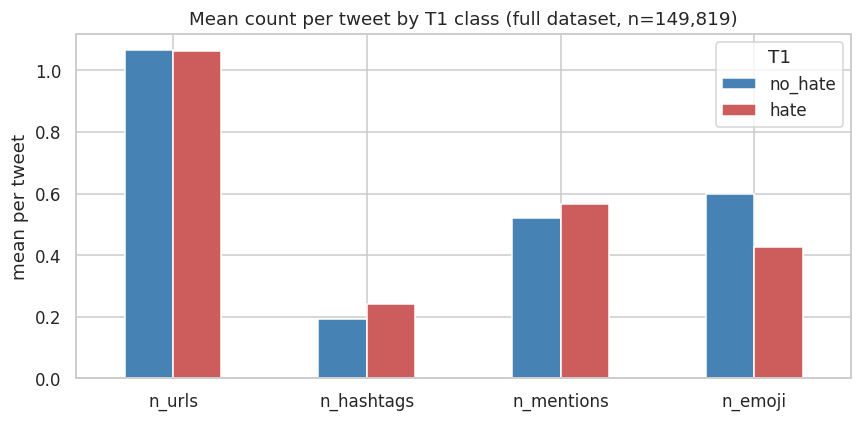


→ Features with ratio meaningfully != 1.0 are signal-bearing for the structured branch.


In [5]:
# Q4 — URL / hashtag / mention / emoji frequency by T1 (full dataset, n=149,819)
# Vectorised pandas.str ops — sampling is unnecessary for short tweet text.

URL_RE     = re.compile(r"https?://\S+")
HASHTAG_RE = re.compile(r"#\w+")
MENTION_RE = re.compile(r"@\w+")
EMOJI_RE = re.compile(
    "["
    "\U0001F1E0-\U0001F1FF"   # regional indicators (flags)
    "\U0001F300-\U0001F5FF"   # symbols & pictographs
    "\U0001F600-\U0001F64F"   # emoticons
    "\U0001F680-\U0001F6FF"   # transport & map symbols
    "\U0001F700-\U0001F77F"   # alchemical symbols
    "\U0001F780-\U0001F7FF"   # geometric extended
    "\U0001F800-\U0001F8FF"   # supplemental arrows-C
    "\U0001F900-\U0001F9FF"   # supplemental symbols & pictographs
    "\U0001FA00-\U0001FA6F"   # chess symbols
    "\U0001FA70-\U0001FAFF"   # symbols & pictographs extended-A
    "\U00002600-\U000027BF"   # misc symbols and dingbats
    "]"
)

feat_df = pd.DataFrame({
    "T1":         df["T1"],
    "n_urls":     df["tweet_text"].str.count(URL_RE),
    "n_hashtags": df["tweet_text"].str.count(HASHTAG_RE),
    "n_mentions": df["tweet_text"].str.count(MENTION_RE),
    "n_emoji":    df["tweet_text"].str.count(EMOJI_RE),
})

agg = feat_df.groupby("T1")[["n_urls", "n_hashtags", "n_mentions", "n_emoji"]].mean().round(3)
agg.index = agg.index.map({0: "no_hate", 1: "hate"})
print(f"Mean per-tweet counts (full dataset, n={len(df):,}):")
print(agg)

# Hate-vs-no-hate ratio
print("\nHate/NoHate ratio (>1 = more common in hate):")
print((agg.loc["hate"] / agg.loc["no_hate"]).round(3))

fig, ax = plt.subplots(figsize=(8, 4))
agg.T.plot(kind="bar", ax=ax, color=["steelblue", "indianred"], edgecolor="white")
ax.set_title(f"Mean count per tweet by T1 class (full dataset, n={len(df):,})")
ax.set_ylabel("mean per tweet")
ax.set_xlabel("")
plt.setp(ax.get_xticklabels(), rotation=0)
ax.legend(title="T1")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "eda_text_features_by_T1.png", dpi=120)
plt.show()

print("\n→ Features with ratio meaningfully != 1.0 are signal-bearing for the structured branch.")


Reading OCR JSONs (full dataset):   0%|          | 0/149819 [00:00<?, ?it/s]

OCR presence and mean length by T2 (full dataset, n=149,819):
           ocr_present_rate  ocr_len_mean       n
T2_name                                          
NotHate               0.388        30.126  112842
Racist                0.382        29.420   11927
Sexist                0.413        31.099    3495
Homophobe             0.368        26.911    3871
Religion              0.620        62.644     163
OtherHate             0.520        55.479    5811


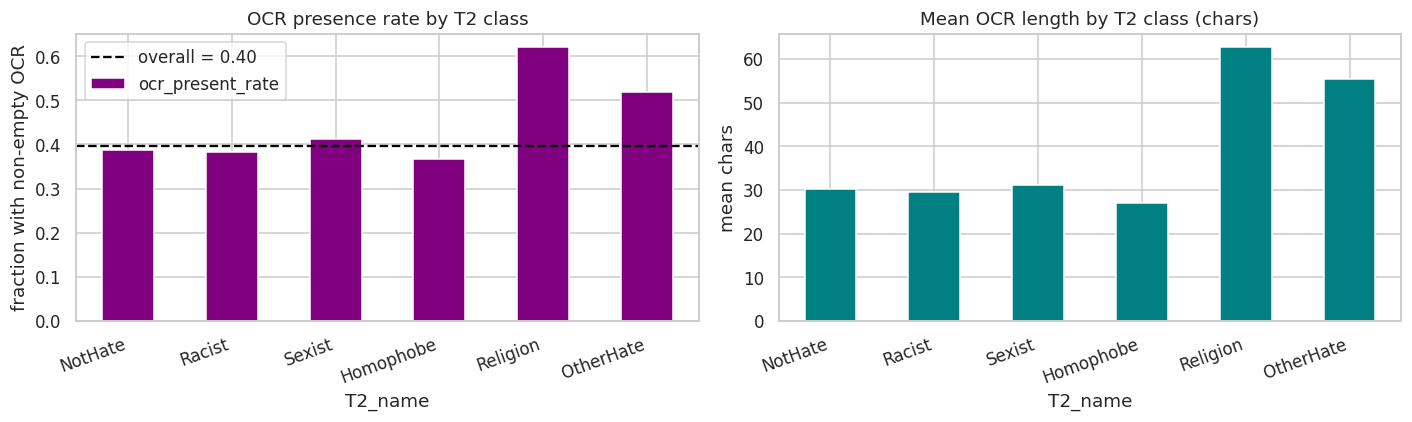


Overall OCR presence: 39.5% of images contain detectable text.
→ If hate-class OCR rate is meaningfully higher than NotHate rate, OCR-only ablation
  has a real shot of being competitive. Watch this in MVP 2.


In [6]:
# Q5 — OCR text presence and length per T2 class (full dataset, n=149,819)
# ThreadPoolExecutor for I/O parallelism on 150K small JSON reads on Windows NTFS.

from concurrent.futures import ThreadPoolExecutor

def read_ocr(tid):
    p = OCR_DIR / f"{tid}.json"
    if not p.exists():
        return ""
    try:
        with open(p, "r", encoding="utf-8") as f:
            return json.load(f).get("img_text", "") or ""
    except Exception:
        return ""

with ThreadPoolExecutor(max_workers=16) as ex:
    ocr_texts = list(tqdm(
        ex.map(read_ocr, df["tweet_id"]),
        total=len(df),
        desc="Reading OCR JSONs (full dataset)",
    ))

ocr_view = df[["tweet_id", "T2"]].copy()
ocr_view["ocr_text"]    = ocr_texts
ocr_view["ocr_len"]     = ocr_view["ocr_text"].str.len()
ocr_view["ocr_present"] = ocr_view["ocr_len"] > 0

ocr_valid = ocr_view.dropna(subset=["T2"]).copy()
ocr_valid["T2_name"] = ocr_valid["T2"].map(T2_LABELS)
ocr_by_t2 = ocr_valid.groupby("T2_name").agg(
    ocr_present_rate=("ocr_present", "mean"),
    ocr_len_mean=("ocr_len", "mean"),
    n=("tweet_id", "count"),
).round(3).reindex(T2_ORDER)
print(f"OCR presence and mean length by T2 (full dataset, n={len(ocr_view):,}):")
print(ocr_by_t2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ocr_by_t2["ocr_present_rate"].plot(kind="bar", ax=axes[0], color="purple", edgecolor="white")
axes[0].set_title("OCR presence rate by T2 class")
axes[0].set_ylabel("fraction with non-empty OCR")
axes[0].axhline(ocr_view["ocr_present"].mean(), color="black", linestyle="--",
                label=f"overall = {ocr_view['ocr_present'].mean():.2f}")
axes[0].legend()
plt.setp(axes[0].get_xticklabels(), rotation=20, ha="right")

ocr_by_t2["ocr_len_mean"].plot(kind="bar", ax=axes[1], color="teal", edgecolor="white")
axes[1].set_title("Mean OCR length by T2 class (chars)")
axes[1].set_ylabel("mean chars")
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "eda_ocr_by_class.png", dpi=120)
plt.show()

overall_pct = ocr_view["ocr_present"].mean() * 100
print(f"\nOverall OCR presence: {overall_pct:.1f}% of images contain detectable text.")
print("→ If hate-class OCR rate is meaningfully higher than NotHate rate, OCR-only ablation")
print("  has a real shot of being competitive. Watch this in MVP 2.")


Reading image dims:   0%|          | 0/1000 [00:00<?, ?it/s]

Image dimensions (sampled n=1,000):
            w       h  aspect  min_side
count  1000.0  1000.0  1000.0    1000.0
mean    654.4   608.2     1.2     500.0
std     203.5   172.9     0.5       0.0
min     500.0   500.0     0.3     500.0
5%      500.0   500.0     0.5     500.0
50%     527.0   500.0     1.1     500.0
95%     953.0   932.7     1.9     500.0
max    2358.0  1734.0     4.7     500.0


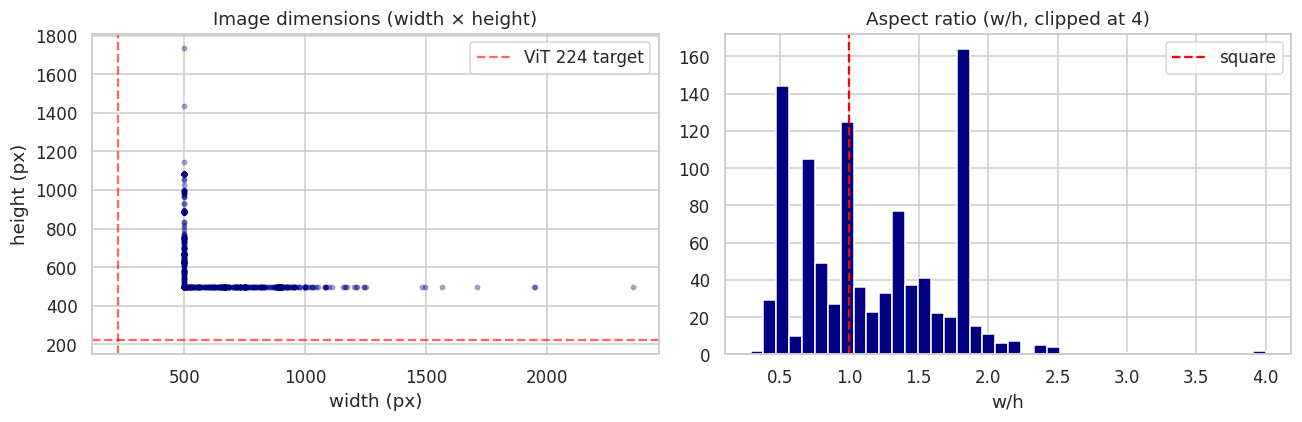


Images with min side < 224 (will require upsample on resize): 0 / 1000 = 0.0%
Aspect range: 5th pct = 0.54, 95th pct = 1.91
→ MMHS150K ships images resized so shortest side >= 500. 224 resize is safe;
  use shortest-side-resize + center-crop (timm default) to preserve aspect.


In [7]:
# Q6 — Image dimension sanity (validates 224x224 resize choice)
# Sample 1k images and read sizes via PIL.

img_pool = df[df["img_exists"]].sample(min(1000, df["img_exists"].sum()), random_state=42)

dims = []
for fname in tqdm(img_pool["img_filename"], desc="Reading image dims"):
    p = IMG_DIR / fname
    try:
        with Image.open(p) as im:
            dims.append(im.size)  # (w, h)
    except Exception:
        dims.append((None, None))

dims_df = pd.DataFrame(dims, columns=["w", "h"]).dropna()
dims_df["aspect"] = dims_df["w"] / dims_df["h"]
dims_df["min_side"] = dims_df[["w", "h"]].min(axis=1)

print(f"Image dimensions (sampled n={len(dims_df):,}):")
print(dims_df.describe(percentiles=[0.05, 0.5, 0.95]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(dims_df["w"], dims_df["h"], alpha=0.3, s=8, color="navy")
axes[0].set_title("Image dimensions (width × height)")
axes[0].set_xlabel("width (px)")
axes[0].set_ylabel("height (px)")
axes[0].axhline(224, color="red", linestyle="--", alpha=0.6, label="ViT 224 target")
axes[0].axvline(224, color="red", linestyle="--", alpha=0.6)
axes[0].legend()

axes[1].hist(dims_df["aspect"].clip(upper=4), bins=40, color="navy", edgecolor="white")
axes[1].set_title("Aspect ratio (w/h, clipped at 4)")
axes[1].set_xlabel("w/h")
axes[1].axvline(1.0, color="red", linestyle="--", label="square")
axes[1].legend()

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "eda_image_dimensions.png", dpi=120)
plt.show()

n_small = int((dims_df["min_side"] < 224).sum())
print(f"\nImages with min side < 224 (will require upsample on resize): {n_small} / {len(dims_df)} = {n_small/len(dims_df)*100:.1f}%")
print(f"Aspect range: 5th pct = {dims_df['aspect'].quantile(0.05):.2f}, 95th pct = {dims_df['aspect'].quantile(0.95):.2f}")
print("→ MMHS150K ships images resized so shortest side >= 500. 224 resize is safe;")
print("  use shortest-side-resize + center-crop (timm default) to preserve aspect.")


Split membership counts:
split
train    134820
test      10000
val        4999
Name: count, dtype: int64

T1 (hate) rate by split:
        count    mean
split                
test    10000  0.5001
train  134820  0.2186
val      4999  0.5001

T2 distribution per split (fractions, NaN excluded):
       NotHate  Racist  Sexist  Homophobe  Religion  OtherHate
split                                                         
test    0.5943  0.1918  0.0552     0.0631    0.0029     0.0927
train   0.8394  0.0757  0.0222     0.0246    0.0010     0.0370
val     0.5954  0.1928  0.0574     0.0603    0.0021     0.0920

Mean T3 per split:
split
test     0.7173
train    0.7854
val      0.7176
Name: T3, dtype: float32


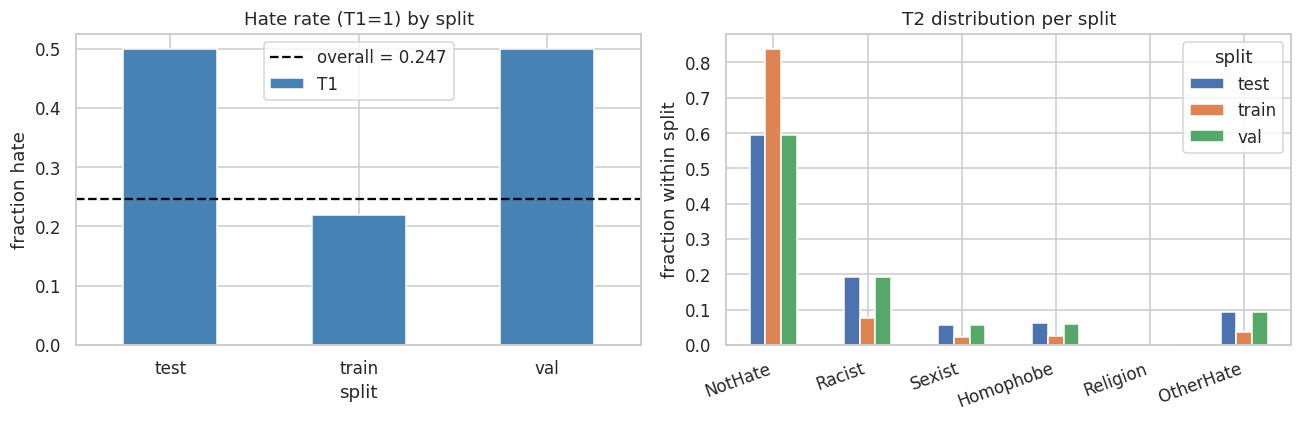


Max |split hate-rate - overall hate-rate|: 0.2533
→ Splits have meaningful T1 imbalance. Report per-split metrics in addition to overall.

df.shape: (149819, 14) | split nulls: 0


In [8]:
# Q7 — Official split balance for T1 / T2 / T3
# Decision is locked: we use the official splits as-is (Gomez 2019 design).
# Goal here is to *know* the imbalances so we report metrics fairly later.

split_member = {}
for split_name in ["train", "val", "test"]:
    ids = (SPLITS_DIR / f"{split_name}_ids.txt").read_text().strip().split()
    for tid in ids:
        split_member[tid] = split_name
df["split"] = df["tweet_id"].map(split_member).fillna("missing")

print("Split membership counts:")
print(df["split"].value_counts())

print("\nT1 (hate) rate by split:")
print(df.groupby("split")["T1"].agg(["count", "mean"]).round(4))

print("\nT2 distribution per split (fractions, NaN excluded):")
t2_per_split = (df.dropna(subset=["T2"])
                  .groupby(["split", "T2"]).size()
                  .unstack(fill_value=0))
t2_per_split = t2_per_split.div(t2_per_split.sum(axis=1), axis=0).round(4)
t2_per_split.columns = [T2_LABELS[c] for c in t2_per_split.columns]
print(t2_per_split)

print("\nMean T3 per split:")
print(df.groupby("split")["T3"].mean().round(4))

# Plot T1 rate per split
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby("split")["T1"].mean().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Hate rate (T1=1) by split")
axes[0].set_ylabel("fraction hate")
axes[0].axhline(df["T1"].mean(), color="black", linestyle="--",
                label=f"overall = {df['T1'].mean():.3f}")
axes[0].legend()
plt.setp(axes[0].get_xticklabels(), rotation=0)

t2_per_split.T.plot(kind="bar", ax=axes[1], edgecolor="white")
axes[1].set_title("T2 distribution per split")
axes[1].set_ylabel("fraction within split")
axes[1].set_xlabel("")
axes[1].legend(title="split")
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "eda_split_balance.png", dpi=120)
plt.show()

# Verdict: how big is the worst split-to-overall hate-rate delta?
deltas = (df.groupby("split")["T1"].mean() - df["T1"].mean()).abs().round(4)
print(f"\nMax |split hate-rate - overall hate-rate|: {deltas.max():.4f}")
if deltas.max() < 0.02:
    print("→ Splits are well-balanced for T1. No need for split-aware metric weighting.")
else:
    print("→ Splits have meaningful T1 imbalance. Report per-split metrics in addition to overall.")

print("\ndf.shape:", df.shape, "| split nulls:", int((df['split']=='missing').sum()))


In [9]:
# Q8 — Were extended-annotator rows (n=4,5) mostly NotHate AAVE / contested?
# The hypothesis from Cell 5 of notebook 01 was: extra annotators are the
# dataset's mechanism for adjudicating ambiguous AAVE / in-group reclamation cases.

extended = df[df["n_annotators"] != 3]
print(f"Total extended-annotator rows (n != 3): {len(extended):,} / {len(df):,} ({len(extended)/len(df)*100:.3f}%)")
print("\nBreakdown by n_annotators:")
print(extended["n_annotators"].value_counts().sort_index())

print("\nT1 distribution (extended vs all):")
extended_rate = extended["T1"].mean()
overall_rate  = df["T1"].mean()
print(f"  hate rate in extended: {extended_rate:.4f}")
print(f"  hate rate overall    : {overall_rate:.4f}")
print(f"  ratio (extended / overall): {extended_rate/overall_rate:.3f}")

print("\nT2 distribution among extended rows (NaN incl):")
print(extended["T2"].value_counts(dropna=False).sort_index())

# Compare T3 (now bounded to [0,1]) for extended vs typical
print("\nMean T3 (extended vs all):")
print(f"  extended: {extended['T3'].mean():.4f}")
print(f"  overall : {df['T3'].mean():.4f}")
print("\n→ If extended rows skew NotHate AND have higher T3 mean, the curation hypothesis holds:")
print("  extra annotators were used to adjudicate originally-disputed cases that turned out non-hate.")


Total extended-annotator rows (n != 3): 70 / 149,819 (0.047%)

Breakdown by n_annotators:
n_annotators
2    30
4    37
5     3
Name: count, dtype: int64

T1 distribution (extended vs all):
  hate rate in extended: 0.2143
  hate rate overall    : 0.2468
  ratio (extended / overall): 0.868

T2 distribution among extended rows (NaN incl):
T2
0       55
1        3
3        1
<NA>    11
Name: count, dtype: Int64

Mean T3 (extended vs all):
  extended: 0.8336
  overall : 0.7786

→ If extended rows skew NotHate AND have higher T3 mean, the curation hypothesis holds:
  extra annotators were used to adjudicate originally-disputed cases that turned out non-hate.


## Summary of findings — implications for downstream notebooks

### Q1 — Image accessibility
- **0 missing images** (149,819 / 149,819 GT-referenced files present on disk).
- **181 orphan** `.jpg` files in `img_resized/` with no GT entry — ignore.
- **No row drop needed** before MVP 2.

### Q2 — Tweet length
- 99th percentile = **24 words** / 139 chars; max = 38 words / 164 chars.
- 100% of tweets are ≤ 128 words.
- `max_seq_len=128` is **adequate**. Decision deferred to MVP 1 — re-verify after RoBERTa BPE tokenisation (BPE typically expands by ~1.3–1.6× word count for English social text).

### Q3 — T3 by T2 class
- **Q25 = Q75 = 0.667 across every hate class** (Racist / Sexist / Homophobe / Religion / OtherHate). The interquartile range of every hate class collapses onto the 2-of-3-agreement point.
- NotHate is unambiguous (mean 0.838, median 1.000).
- **Sexist is the lowest-agreement class** (mean T3 = 0.705).
- **Confirms the T3 deployment-routing premise.** Every hate class has ambiguous majority-vote cases; Sexist is the strongest candidate for human-review routing.

### Q4 — Text features by T1 (full dataset, n=149,819)
- **Hashtags: +26%** in hate (signal-bearing — stronger than the 20K-sample estimate of +20%).
- **Mentions: +9%** in hate (weaker than the 20K-sample estimate of +14% — direction holds but magnitude tempered on full dataset).
- **Emoji: -29%** in hate (inverse signal — counterintuitive but real; slightly stronger than the sample's -27%).
- **URLs: ratio ≈ 1.0** — every tweet has the embedded `t.co/...` link, so the count carries no signal. **Use as binary `url_present` instead of a count** (already adopted in notebook 03; correlation gate confirmed `url_present` is zero-variance).

### Q5 — OCR text presence and length by T2 class (full dataset, n=149,819)
- **39.5% overall OCR coverage** of MMHS150K images.
- **OtherHate: 52.0%** OCR rate (mean 55 chars) — clearly meme-heavy.
- **Religion: 62.0%** OCR rate (mean 63 chars, **n=163** — defensible vs the 10-row sample's noisy 70% estimate). Meme-driven pattern holds firmly.
- Other hate classes hover at 37–41% OCR rate (NotHate 38.8%, Racist 38.2%, Sexist 41.3%, Homophobe 36.8%).
- **Implication:** the OCR-only ablation cell in MVP 2 is genuinely competitive on text-heavy classes (OtherHate, Religion); for the rest it will track text-only baseline closely.

### Q6 — Image dimensions (sampled, n=1,000 — image reads are slow, sample is fine)
- All sampled images have `min_side ≥ 500` (dataset is pre-resized).
- 0% require upsampling to 224×224.
- Aspect range (5th–95th pct): 0.54–1.91.
- **Standard timm preprocessing (shortest-side-resize → center-crop to 224) is fine.**

### Q7 — Official split balance (LOAD-BEARING METHODOLOGICAL FINDING)
- **Train: hate rate 21.86%** (natural distribution).
- **Val:   hate rate 50.01%** (engineered 50/50 by Gomez 2019).
- **Test:  hate rate 50.01%** (engineered 50/50 by Gomez 2019).
- Mean T3 follows: train 0.785, val/test 0.717.
- **Reporting rule (per CLAUDE.md §9):** always report BOTH (a) balanced-test metrics (raw val/test numbers), and (b) recalibrated-distribution metrics (Bayes-shift to ~22% hate).
- **Class weighting in training loss must use the train distribution (~22% hate)**, NOT val/test.

### Q8 — Extended-annotator pattern
- 70 rows with n_annotators ∈ {2, 4, 5} (0.047% of dataset).
- Hate rate among extended rows: 21.4% (vs 24.7% overall).
- Mean T3 among extended rows: 0.834 (vs 0.779 overall).
- **Hypothesis confirmed:** extra annotators were brought in to adjudicate originally-disputed cases that turned out to be non-hate (mostly AAVE / in-group reclamation language). Documented in Cell 5 of notebook 01.

---

**All EDA findings drive decisions in notebook 03 (structured features) and downstream MVPs.**
